# Tutorial 3c: Stepped Optimization and DLS/LM

This tutorial is a deep dive into Optiland's **native Levenberg-Marquardt (DLS)** solver — the workhorse of classical lens design — and its close relatives.

By the end you will know how to:

* read the DLS update equation and understand the **damping** parameter λ;
* tune the `LevenbergController` (now using **Nielsen gain-ratio** adaption);
* run the un-damped `GaussNewton` variant safely (it has an Armijo **descent guard**);
* impose **box bounds** on variables;
* impose **hard equality / inequality constraints** with `add_constraint(...)`, solved
  exactly by a **KKT active-set** step — and read back the Lagrange **multipliers** and
  **active set**.

**Prerequisite:** [Tutorial 3b](Tutorial_3b_Choosing_a_Method.ipynb) (method selection).
[Tutorial 3d](Tutorial_3d_Inspecting_and_Controlling_a_Run.ipynb) covers observers, stopping
criteria, and run diagnostics in depth.

## 1. Setup

In [1]:
import numpy as np

from optiland import optic
from optiland.optimization import (
    minimize,
    OptimizationProblem,
    LevenbergController,
    LevenbergMarquardt,
    GaussNewton,
)
from optiland.optimization.errors import ConfigurationError

Build a cemented doublet as the working example.

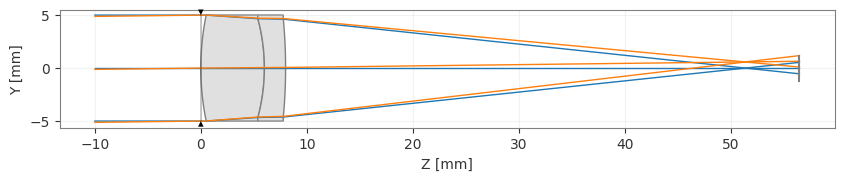

In [2]:
def make_doublet():
    lens = optic.Optic()
    lens.surfaces.add(index=0, thickness=np.inf)
    lens.surfaces.add(index=1, thickness=6.0, radius=25.0, material='N-BK7', is_stop=True)
    lens.surfaces.add(index=2, thickness=2.0, radius=-18.0, material='N-SF11')
    lens.surfaces.add(index=3, thickness=0.5, radius=-50.0)
    lens.surfaces.add(index=4, thickness=48.0)
    lens.surfaces.add(index=5)
    lens.set_aperture(aperture_type='EPD', value=10)
    lens.fields.set_type('angle')
    lens.fields.add(y=0.0)
    lens.fields.add(y=0.7)
    lens.wavelengths.add(value=0.4861)
    lens.wavelengths.add(value=0.5876, is_primary=True)
    lens.wavelengths.add(value=0.6563)
    return lens

lens = make_doublet()
_ = lens.draw()

## 2. The DLS algorithm

Levenberg-Marquardt minimizes a sum-of-squares merit function
$F(x) = \sum_i r_i(x)^2$ by repeatedly solving the **damped normal equations**

```
(JᵀJ + λ D) Δx = -Jᵀr
```

where `J` is the Jacobian of the residual vector `r`, and `D` is a diagonal scaling
(Moré damping, `D = diag(JᵀJ)`).

* **Large λ** → a small, gradient-descent-like step (safe far from the solution).
* **Small λ** → a fast Gauss-Newton step (efficient near the solution).

The `LevenbergController` adapts λ automatically after every trial step using the
**Nielsen gain ratio** ρ = (actual reduction) / (predicted reduction):

* ρ > 0 → the step is accepted and λ is *decreased* by
  `λ · max(⅓, 1−(2ρ−1)³)` (bigger trust region next time);
* ρ ≤ 0 → the step is rejected and λ is *increased* geometrically (`λ · ν`, `ν ← 2ν`).

## 3. Default DLS run

In [3]:
def make_problem(lens):
    problem = OptimizationProblem()
    for field in lens.fields.get_field_coords():
        input_data = {'optic': lens, 'surface_number': -1,
                      'Hx': field[0], 'Hy': field[1],
                      'num_rays': 5, 'wavelength': 0.5876, 'distribution': 'hexapolar'}
        problem.add_operand('rms_spot_size', target=0, weight=1, input_data=input_data)
    problem.add_operand('f2', target=100, weight=1, input_data={'optic': lens})
    for s in [1, 2, 3]:
        problem.add_variable(lens, 'radius', surface_number=s)
    problem.add_variable(lens, 'thickness', surface_number=4, min_val=30, max_val=80)
    return problem

problem = make_problem(lens)
result = minimize(problem, 'dls')
print(result)

Optimization started — initial merit = 2813.11
  iter     1 | merit = 2327.15
  iter     2 | merit = 1257.91
  iter     3 | merit = 223.508
  iter     4 | merit = 10.9735
  iter     5 | merit = 0.347065
  iter     6 | merit = 0.057806
  iter     7 | merit = 0.0570509
  iter     7 | merit = 0.0570509
Optimization ended  — final merit = 0.0570509  (+100.00%)  [lm_lambda_max: all trials rejected]
OptimizationResult(x=array([-0.69645844, -1.13816536, -1.66255807,  7.        ]), success=False, status='lm_lambda_max: all trials rejected', value=0.057050929870366335, initial_value=2813.1094190774606, improvement_pct=99.99797196193353, iterations=7, n_value_evals=24, n_jac_evals=8, wall_time_s=0.27985399999306537, history=None, backend='numpy', method='dls', resolved_from=None, multipliers=None, active_set=None, constraint_report=None, max_constraint_violation=None, grad_norm=154.57195819453295, lambda_final=2.0001446673495826e+19, cond_estimate=4.5937077329678656e+17)


In [4]:
problem.info()

╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │                1.41098 │           99.9498 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │   0.84  │   0.84  │          50.05 │
│  1 │ rms spot size  │        0 │              │              │        1 │             1 │   0.839 │   0.839 │          49.95 │
│  2 │ f2             │      100 │              │              │        1 │             1 │  99

## 4. Tuning the `LevenbergController`

The controller exposes a handful of knobs. With the Nielsen adaption the most useful are
`lam_init` (the starting λ), `lam_max` (a safety cap), `min_diag` (a floor on the Moré
diagonal), and `max_trials` (inner λ-search budget per accepted step).

| Parameter | Meaning | Tip |
|-----------|---------|-----|
| `lam_init` | Starting λ — higher = more conservative first step | Decrease for well-conditioned problems |
| `lam_max` | Safety cap — the run stops if λ exceeds this | Raise if you hit early termination |
| `min_diag` | Floor on `diag(JᵀJ)` so damping stays positive | Rarely changed |
| `max_trials` | Max inner λ trials per accepted step | Raise for very stiff problems |

In [5]:
lens2 = make_doublet()
problem2 = make_problem(lens2)

# A smaller lam_init starts more aggressively (closer to Gauss-Newton).
ctrl = LevenbergController(lam_init=1e-4, lam_max=1e10)
result2 = minimize(problem2, 'dls', controller=ctrl)
print(result2)

Optimization started — initial merit = 2813.11
  iter     1 | merit = 14.109
  iter     2 | merit = 2.2532
  iter     3 | merit = 0.157153
  iter     4 | merit = 0.0766636
  iter     4 | merit = 0.0766636
Optimization ended  — final merit = 0.0766636  (+100.00%)  [lm_lambda_max: all trials rejected]
OptimizationResult(x=array([-0.70481445, -1.13011317, -1.62775988,  7.        ]), success=False, status='lm_lambda_max: all trials rejected', value=0.0766636226623956, initial_value=2813.1094190774606, improvement_pct=99.99727477281395, iterations=4, n_value_evals=18, n_jac_evals=5, wall_time_s=0.19326819998968858, history=None, backend='numpy', method='dls', resolved_from=None, multipliers=None, active_set=None, constraint_report=None, max_constraint_violation=None, grad_norm=202.78452618538927, lambda_final=12648672567.042526, cond_estimate=8.249367526974284e+17)


## 5. `GaussNewton` (un-damped) with a descent guard

`method='gauss_newton'` solves the *un-damped* normal equations `(JᵀJ)Δx = -Jᵀr`
(i.e. λ = 0).  Historically, undamped Gauss-Newton could **diverge** spectacularly far
from the solution.  Optiland's `GaussNewton` now wraps each step in an **Armijo descent
guard**: if a full step would increase the merit, it backtracks, and on persistent
increase it takes a single damped (LM) fallback step.  The result is robust convergence
even from a poor starting point.

In [6]:
lens4 = make_doublet()
problem4 = make_problem(lens4)
result4 = minimize(problem4, 'gauss_newton')
print(result4)

Optimization started — initial merit = 2813.11
  iter     1 | merit = 1267.8
  iter     2 | merit = 42.8138
  iter     3 | merit = 7.0117
  iter     4 | merit = 0.00912069
  iter     5 | merit = 8.77557e-05
  iter     6 | merit = 0.000102135
  iter     7 | merit = 0.000102208
Optimization ended  — final merit = 0.000102208  (+100.00%)  [cost_tol=1.00e-03 (rel_change=7.16e-04)]
OptimizationResult(x=array([-0.08811838, -3.49653919, -2.41786872,  7.        ]), success=True, status='cost_tol=1.00e-03 (rel_change=7.16e-04)', value=0.00010220783502378734, initial_value=2813.1094190774606, improvement_pct=99.99999636673091, iterations=7, n_value_evals=169, n_jac_evals=7, wall_time_s=0.8041442000103416, history=None, backend='numpy', method='gauss_newton', resolved_from=None, multipliers=None, active_set=None, constraint_report=None, max_constraint_violation=None, grad_norm=None, lambda_final=None, cond_estimate=None)


## 6. Variable bounds

Add `min_val` / `max_val` to `add_variable(...)`.  With the default `bounds=True`, the
stepped optimizer keeps each parameter inside its box at every accepted step.  (When a
step is clamped to a bound, the live optic and the reported `result.x` are re-synced, so
they always agree.)

In [7]:
lens5 = make_doublet()

problem5 = OptimizationProblem()
for field in lens5.fields.get_field_coords():
    input_data = {'optic': lens5, 'surface_number': -1,
                  'Hx': field[0], 'Hy': field[1],
                  'num_rays': 5, 'wavelength': 0.5876, 'distribution': 'hexapolar'}
    problem5.add_operand('rms_spot_size', target=0, weight=1, input_data=input_data)
problem5.add_operand('f2', target=50, weight=1, input_data={'optic': lens5})
for s in [1, 2, 3]:
    problem5.add_variable(lens5, 'radius', surface_number=s, min_val=10, max_val=200)
problem5.add_variable(lens5, 'thickness', surface_number=4, min_val=30, max_val=80)

result5 = minimize(problem5, 'dls', bounds=True)  # note: bounds=True is default. We write it to be explicit here.
print(result5)

Optimization started — initial merit = 9.58183
  iter     1 | merit = 0.0387353
  iter     1 | merit = 0.0387353
Optimization ended  — final merit = 0.0387353  (+99.60%)  [lm_lambda_max: all trials rejected]
OptimizationResult(x=array([-0.74433136, -0.9       , -0.9       ,  3.62798825]), success=False, status='lm_lambda_max: all trials rejected', value=0.03873525942117496, initial_value=9.581831818837673, improvement_pct=99.59574264969854, iterations=1, n_value_evals=13, n_jac_evals=2, wall_time_s=0.09098740000627004, history=None, backend='numpy', method='dls', resolved_from=None, multipliers=None, active_set=None, constraint_report=None, max_constraint_violation=None, grad_norm=245505.8587412794, lambda_final=2.4595658764946068e+16, cond_estimate=3.395254885633087e+16)


## 7. Hard constraints via `add_constraint` (KKT active set)

Box bounds constrain a single *variable*. To constrain a *quantity* — a focal length, an edge thickness, a paraxial property — declare a **hard constraint** on the problem:

```python
problem.add_constraint(operand_type, target=...,            # equality  c(x) = value − target = 0
                       min_val=..., max_val=...,            # inequality g(x) ≤ 0
                       input_data={...}, tol=...)
```

When at least one hard constraint is present, the native LM solver switches to a **KKT active-set controller** that solves the *damped KKT system*:

$$\begin{bmatrix} J^TJ + \lambda D & A^T \\ A & 0 \end{bmatrix} \begin{bmatrix} \Delta x \\ \mu \end{bmatrix} = \begin{bmatrix} -J^Tr \\ b \end{bmatrix}$$

where $A$ stacks the constraint Jacobians of the equalities **and** the currently-active inequalities, and $b$ drives the linearized constraints toward feasibility. The controller maintains an **active set** (adding bounds the step would violate, releasing bounds whose Lagrange multiplier turns the wrong sign) so inequalities are honored exactly at the solution.

Hard constraints require a KKT-capable method (`'dls'` or `'lm'`); `method='auto'` routes to `'dls'` automatically when constraints are present.

### Equality: hold the focal length while improving the spot

A classic requirement: *improve image quality without changing the effective focal length*. We constrain `f2` to its starting value and let the radii vary to minimize the RMS spot size.

In [8]:
lens6 = make_doublet()
f2_start = float(lens6.paraxial.f2())

problem6 = OptimizationProblem()
for field in lens6.fields.get_field_coords():
    input_data = {'optic': lens6, 'surface_number': -1,
                  'Hx': field[0], 'Hy': field[1],
                  'num_rays': 5, 'wavelength': 0.5876, 'distribution': 'hexapolar'}
    problem6.add_operand('rms_spot_size', target=0, weight=1, input_data=input_data)
for s in [1, 2, 3]:
    problem6.add_variable(lens6, 'radius', surface_number=s)

# Hard equality: keep f2 fixed at its starting value.
problem6.add_constraint('f2', target=f2_start, input_data={'optic': lens6}, tol=1e-4)

result6 = minimize(problem6, 'dls', maxiter=60, disp=False)
print(f'f2: start = {f2_start:.4f} mm,  final = {lens6.paraxial.f2():.4f} mm')
print(f'spot merit: {result6.initial_value:.4f} -> {result6.value:.4f}')
print(f'max constraint violation: {result6.max_constraint_violation:.2e}')
print(f'Lagrange multipliers: {result6.multipliers}')

f2: start = 46.9647 mm,  final = 46.9647 mm
spot merit: 0.3689 -> 0.0408
max constraint violation: 1.71e-05
Lagrange multipliers: {'f2==46.96472412741376': 0.010418328751929988}


The focal length is held to within the tolerance (tiny `max_constraint_violation`) while
the spot merit drops by roughly an order of magnitude.  `result.multipliers` reports the
Lagrange multiplier for the equality — its magnitude is the sensitivity of the optimal
merit to relaxing that constraint.

### Inequality: keep a quantity above a floor

Now suppose the merit *wants* to shrink `f2` (we add a competing `f2` target well below
the start), but design rules require `f2 ≥ floor`.  The KKT active set lets the bound
**bind**: the optimizer rides along the constraint surface.

In [9]:
lens7 = make_doublet()
f2_start = float(lens7.paraxial.f2())
floor = 0.85 * f2_start

problem7 = OptimizationProblem()
# Competing objective: drive f2 well below the floor.
problem7.add_operand('f2', target=0.6 * f2_start, weight=1.0, input_data={'optic': lens7})
problem7.add_variable(lens7, 'radius', surface_number=1)
problem7.add_variable(lens7, 'radius', surface_number=3)

# Hard inequality floor: f2 >= floor.
problem7.add_constraint('f2', min_val=floor, input_data={'optic': lens7}, tol=1e-3)

result7 = minimize(problem7, 'dls', maxiter=120)
print(f'floor = {floor:.4f} mm,  f2 final = {lens7.paraxial.f2():.4f} mm')
print(f'max constraint violation: {result7.max_constraint_violation:.2e}')
print(f'active set: {result7.active_set}')
print(f'multipliers (>=0 when binding): {result7.multipliers}')

Optimization started — initial merit = 352.91
  iter     1 | merit = 147.12
  iter     2 | merit = 137.759
  iter     3 | merit = 136.862
  iter     4 | merit = 128.906
  iter     5 | merit = 69.3305
  iter     6 | merit = 34.6679
  iter     7 | merit = 140.208
  iter     8 | merit = 137.855
  iter     9 | merit = 137.855
Optimization ended  — final merit = 137.855  (+60.94%)  [cost_tol=1.00e-03 (rel_change=8.86e-07)]
floor = 39.9200 mm,  f2 final = 39.9200 mm
max constraint violation: 3.28e-10
active set: ['f2>=39.920015508301695']
multipliers (>=0 when binding): {'f2>=39.920015508301695': 11.741093849595071}


`f2` settles **exactly on the floor**, the active set lists the binding inequality, and
its multiplier is **positive** — the correct KKT sign for an active `g(x) ≤ 0` bound.

The final merit of ≈ 138 is not a failure — it is the **minimum achievable** given the
constraint.  The single operand is `(f2 − target)²`, and because `target = 0.6 · f2_start`
lies *below* the floor `0.85 · f2_start`, the optimizer cannot reach the unconstrained
minimum.  The best it can do is park `f2` exactly on the floor, giving a residual of
`floor − target ≈ 11.74 mm` and a merit of `11.74² ≈ 138`.  Notice that the Lagrange
multiplier reported above is also ≈ 11.74 — this is a direct consequence of the KKT
stationarity condition `∂F/∂x + μ ∂g/∂x = 0` evaluated at the solution.

In [10]:
lens8 = make_doublet()
problem8 = make_problem(lens8)
problem8.add_constraint('f2', target=100.0, input_data={'optic': lens8})
try:
    minimize(problem8, 'l-bfgs-b')
except ConfigurationError as exc:
    print('ConfigurationError:', exc)

ConfigurationError: Problem declares 1 hard constraint(s) via add_constraint(), which require a KKT-capable stepped method ('dls' or 'lm'). Method 'l-bfgs-b' does not support hard equality/inequality constraints. Either switch to method='dls', or express the requirement as a soft penalty operand (add_operand with min_val/max_val).


## 8. Summary

| Feature | How to enable |
|---------|---------------|
| Default DLS (Nielsen gain-ratio) | `minimize(problem, 'dls')` |
| Custom λ schedule | `controller=LevenbergController(lam_init=..., lam_max=...)` |
| Un-damped Gauss-Newton (descent-guarded) | `minimize(problem, 'gauss_newton')` |
| Box bounds | `add_variable(..., min_val=..., max_val=...)` + `bounds=True` |
| Hard equality | `add_constraint(type, target=..., input_data=...)` |
| Hard inequality | `add_constraint(type, min_val=..., max_val=..., input_data=...)` |
| Read multipliers / active set | `result.multipliers`, `result.active_set` |

**Next:** [Tutorial 3d](Tutorial_3d_Inspecting_and_Controlling_a_Run.ipynb) — observers,
stopping criteria, and the full set of run diagnostics.